In [1]:
#Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
#PREPROCESSING
# Load the Uber reviews dataset
df = pd.read_csv("uber_reviews.csv")

# Display first rows
df.head()

,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,User_0,NaN,Good,5,0,4.556.10005,2024-12-18 17:17:19,NaN,NaN,4.556.10005
1,User_1,NaN,Nice,5,0,4.556.10005,2024-12-18 17:17:17,NaN,NaN,4.556.10005
2,User_2,NaN,Very convenient,5,0,4.532.10001,2024-12-18 17:09:42,NaN,NaN,4.532.10001
3,User_3,NaN,Good,4,0,4.556.10005,2024-12-18 17:08:27,NaN,NaN,4.556.10005
4,User_4,NaN,exllence,5,0,4.556.10005,2024-12-18 17:08:16,NaN,NaN,4.556.10005


In [5]:
#Check dataset shape
df.shape

(12000, 10)

In [6]:
#Dataset info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   userName              12000 non-null  str    
 1   userImage             0 non-null      float64
 2   content               12000 non-null  str    
 3   score                 12000 non-null  int64  
 4   thumbsUpCount         12000 non-null  int64  
 5   reviewCreatedVersion  10260 non-null  str    
 6   at                    12000 non-null  str    
 7   replyContent          33 non-null     str    
 8   repliedAt             33 non-null     str    
 9   appVersion            10260 non-null  str    
dtypes: float64(1), int64(2), str(7)
memory usage: 937.6 KB


In [7]:
#Check for missing values
df.isnull().sum()

userName                    0
userImage               12000
content                     0
score                       0
thumbsUpCount               0
reviewCreatedVersion     1740
at                          0
replyContent            11967
repliedAt               11967
appVersion               1740
dtype: int64

In [8]:
#Keep only review text and rating columns
df = df[['content', 'score']]
df.head()

,content,score
0,Good,5
1,Nice,5
2,Very convenient,5
3,Good,4
4,exllence,5


In [10]:
#Convert scores into sentiment labels
def convert_label(score):
    if score in [4, 5]:
        return 1   # positive
    elif score in [1, 2]:
        return 0   # negative
    else:
        return None  # neutral

df['sentiment'] = df['score'].apply(convert_label)

# Remove rows where sentiment is None (neutral reviews)
df = df.dropna(subset=['sentiment'])

df['sentiment'] = df['sentiment'].astype(int)

df.tail()

,content,score,sentiment
11995,Excellent!!!,5,1
11996,Worst experience after 10pm in Hyde cityno aut...,5,1
11997,Exceptional,5,1
11998,Good Service.,5,1
11999,"Very bad experience with this app, booked a sh...",1,0


In [12]:
#Check class balance-Count positive vs negative
df['sentiment'].value_counts()

sentiment
1    8732
0    2935
Name: count, dtype: int64

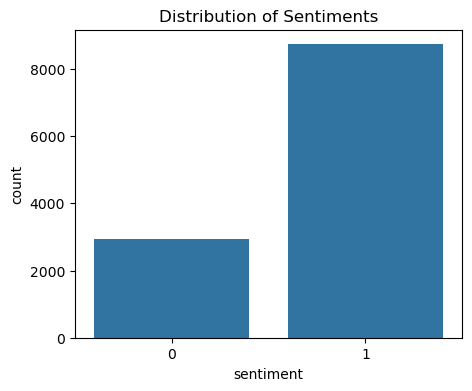

In [13]:
plt.figure(figsize=(5,4))
sns.countplot(x=df['sentiment'])
plt.title("Distribution of Sentiments")
plt.show()

In [14]:
#Split into train and test sets
X = df['content']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
#Initialize TF-IDF vectorizer
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

# Fit and transform training data
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform test data
X_test_tfidf = tfidf.transform(X_test)

In [16]:
#MODELING
#Train Logistic Regression Model
model = LogisticRegression(max_iter=400)
model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,400
,multi_class,'deprecated'


In [17]:
#EVALUATION
#Predict test set results
y_pred = model.predict(X_test_tfidf)

In [18]:
#Accuracy
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.9468723221936589

In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.85      0.89       610
           1       0.95      0.98      0.96      1724

    accuracy                           0.95      2334
   macro avg       0.94      0.92      0.93      2334
weighted avg       0.95      0.95      0.95      2334



In [20]:
cm = confusion_matrix(y_test, y_pred)

array([[ 520,   90],
       [  34, 1690]])

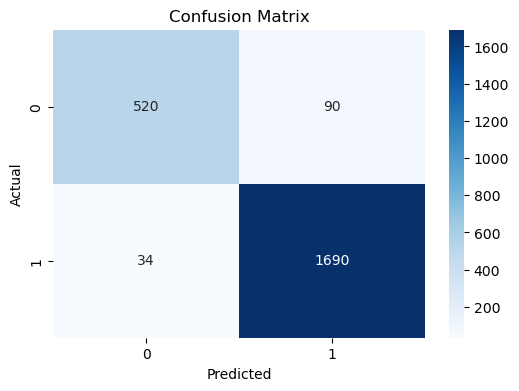

In [21]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [23]:
#Custom test sentences with predicted sentiment labels

samples = [
    "The app is amazing and the service is very fast",
    "Worst experience ever. The driver was rude",
    "Not great, not bad, average"
]

# Transform using TF-IDF
sample_tfidf = tfidf.transform(samples)

# Predict labels
predictions = model.predict(sample_tfidf)

# Mapping for display
sentiment_map = {1: "Positive (1)", 0: "Negative (0)"}

# Print predictions with meaning
for text, label in zip(samples, predictions):
    print("Review:", text)
    print("Predicted Sentiment:", sentiment_map[label])
    print()

Review: The app is amazing and the service is very fast
Predicted Sentiment: Positive (1)

Review: Worst experience ever. The driver was rude
Predicted Sentiment: Negative (0)

Review: Not great, not bad, average
Predicted Sentiment: Positive (1)

